### Regression Exercise 
# Moneyball The NBA
---

### This HW is not easy. TRY IT YOURSELF FIRST! 
Then If you are able to complete it, [watch this lecture series on it](https://ocw.mit.edu/courses/15-071-the-analytics-edge-spring-2017/pages/linear-regression/playing-moneyball-in-the-nba-recitation/video-1-the-data/). 

In [249]:
# PANDAS IS FOR DATA WRANGLING
import pandas as pd
import numpy as np

# SEABORN IS A PLOTTING LIBRARY
import seaborn as sns

# MATPLOT LIB IS ALSO A PLOTTING LIBRARY
import matplotlib.pyplot as plt

# SKLEARN IS OUR MACHINE LEARNING PACKAGE
from sklearn.linear_model import LinearRegression

# IMPORT OUR RANDOM FOREST REGERSSOR
from sklearn.ensemble import RandomForestRegressor

# METRICS HELP US SCORE OUR MODEL
from sklearn import metrics

# HELP US SPLIT OUR DATA INTO TESTING A TRAINING
from sklearn.model_selection import train_test_split

# Good ol statsmodels
import statsmodels.api as sm

# Specific root mean squared error for stats models
from statsmodels.tools.eval_measures import rmse


from statsmodels.stats.outliers_influence import variance_inflation_factor


from statsmodels.api import qqplot

# import CTPLIB as ctp


# Remember our main steps motto _isbe_.
1. i - Inspect and explore data.
2. s - Select and engineer features.
3. b - Build and train model.
4. e - Evaluate model.

# STEP 1 (i): Inspect and explore data
1. Use `data/NBA_test.csv and data/NBA_train.csv`

In [250]:
# READ IN THE DATA USING PANDAS 
df = pd.read_csv('../data/NBA_train.csv')


# DISPLAY THE FIRST 5 ROWS
df.head()

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
0,1980,Atlanta Hawks,1,50,8573,8334,3261,7027,3248,6952,13,75,2038,2645,1369,2406,1913,782,539,1495
1,1980,Boston Celtics,1,61,9303,8664,3617,7387,3455,6965,162,422,1907,2449,1227,2457,2198,809,308,1539
2,1980,Chicago Bulls,0,30,8813,9035,3362,6943,3292,6668,70,275,2019,2592,1115,2465,2152,704,392,1684
3,1980,Cleveland Cavaliers,0,37,9360,9332,3811,8041,3775,7854,36,187,1702,2205,1307,2381,2108,764,342,1370
4,1980,Denver Nuggets,0,30,8878,9240,3462,7470,3379,7215,83,255,1871,2539,1311,2524,2079,746,404,1533


```
SeasonEnd: Year season ended
Team: Name of team
Playoffs: If they made the playoffs. 1 == made to playoffs
W: Number of regular season in that season. 
PTS: Points scored in regular season. 
oppPTS: Opponent Points scored in regular season. 
FG: Field Goals made (total shots made == 2P and 3P combined)
FGA: Field Goals attempted (total shots attempted == 2P and 3P combined)
2P: two-pointers made
2PA: two-pointers attempted
3P: three-pointers made
3PA: three-pointers attempted
FT: Free-Throws made (not included in FG stat)
FTA: Free-Throws attempted (not included in FG stat)
ORB: Offensive Rebounds
DRB: Defensive Rebounds
AST: Assists made
STL: Steals 
BLK: Blocks 
TOV: Turnovers 
```

#### Inspect our data using `df.describe()` function.

In [251]:
# Inspect our data using `df.describe()` function.
df.describe()

,SeasonEnd,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
count,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,1996.319760,0.574850,41.000000,8370.239521,8370.239521,3200.367665,6873.318563,2881.324551,5956.444311,319.043114,916.874251,1650.461078,2189.953293,1061.584431,2427.354491,1912.112575,668.364072,419.805988,1302.837126
std,9.243808,0.494662,12.740822,581.040114,587.543959,287.181266,401.027166,446.097941,830.596327,199.698941,523.982964,197.651728,244.491086,150.224519,130.671523,221.610925,93.393044,82.274913,153.973470
min,1980.000000,0.000000,11.000000,6901.000000,6909.000000,2565.000000,5972.000000,1981.000000,4153.000000,10.000000,75.000000,1189.000000,1475.000000,639.000000,2044.000000,1423.000000,455.000000,204.000000,931.000000
25%,1989.000000,0.000000,31.000000,7934.000000,7934.000000,2974.000000,6563.500000,2510.000000,5269.000000,131.500000,413.000000,1502.500000,2008.000000,953.500000,2346.500000,1735.000000,599.000000,359.000000,1192.000000
50%,1996.000000,1.000000,42.000000,8312.000000,8365.000000,3150.000000,6831.000000,2718.000000,5706.000000,329.000000,942.000000,1628.000000,2176.000000,1055.000000,2433.000000,1899.000000,658.000000,410.000000,1289.000000
75%,2005.000000,1.000000,50.500000,8784.500000,8768.500000,3434.500000,7157.000000,3296.000000,6753.500000,481.500000,1347.500000,1781.000000,2352.000000,1167.000000,2516.500000,2077.500000,729.000000,469.500000,1395.500000
max,2011.000000,1.000000,72.000000,10371.000000,10723.000000,3980.000000,8868.000000,3954.000000,7873.000000,841.000000,2284.000000,2388.000000,3051.000000,1520.000000,2753.000000,2575.000000,1053.000000,716.000000,1873.000000


#### Check for Nulls.

In [252]:
# Check for Nulls.
df.isna().sum()

SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64

#### Check for Duplicates

In [253]:
# Check for Duplicates
df.duplicated().sum()

np.int64(0)

#### Build a function that will INSPECT ANY DATAFRAME FOR YOU do this for you for any data frame you pass into it.

In [254]:
def inspect_dataframe(input_df):
    """Print DataFrame inspection"""

    print("### DataFrame Info")
    print(input_df.info())
    print("\n### DataFrame Shape")
    print(f"Rows: {input_df.shape[0]}, Columns: {input_df.shape[1]}")
    print("### DataFrame Description")
    print(input_df.describe())
    print()

    print("\n### Missing Values / Nulls Per Column")
    print(input_df.isna().sum())
    print("\n### Missing Values / Nulls Total")
    print(input_df.isna().sum().sum())
    print("\n### Duplicates Per Column")
    print(input_df.duplicated().sum())
    print("\n### Duplicates Total")
    print(input_df.duplicated().sum().sum())
    print("\n### Unique Values Per Column")
    print(input_df.nunique())
    print()

    print("\n### Descriptive Statistics")
    print(input_df.describe(include='all'))
    print("\n### Data Types")
    print(input_df.dtypes)

    print("\n### Head")
    print(input_df.head())


inspect_dataframe(df)


### DataFrame Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   SeasonEnd  835 non-null    int64 
 1   Team       835 non-null    object
 2   Playoffs   835 non-null    int64 
 3   W          835 non-null    int64 
 4   PTS        835 non-null    int64 
 5   oppPTS     835 non-null    int64 
 6   FG         835 non-null    int64 
 7   FGA        835 non-null    int64 
 8   2P         835 non-null    int64 
 9   2PA        835 non-null    int64 
 10  3P         835 non-null    int64 
 11  3PA        835 non-null    int64 
 12  FT         835 non-null    int64 
 13  FTA        835 non-null    int64 
 14  ORB        835 non-null    int64 
 15  DRB        835 non-null    int64 
 16  AST        835 non-null    int64 
 17  STL        835 non-null    int64 
 18  BLK        835 non-null    int64 
 19  TOV        835 non-null    int64 
dtypes: int64(19),

#### Get a sense of how many wins it will take to make the playoffs. 
Make a scatter plot with x=Wins and the y=Team, and the hue=Playoffs

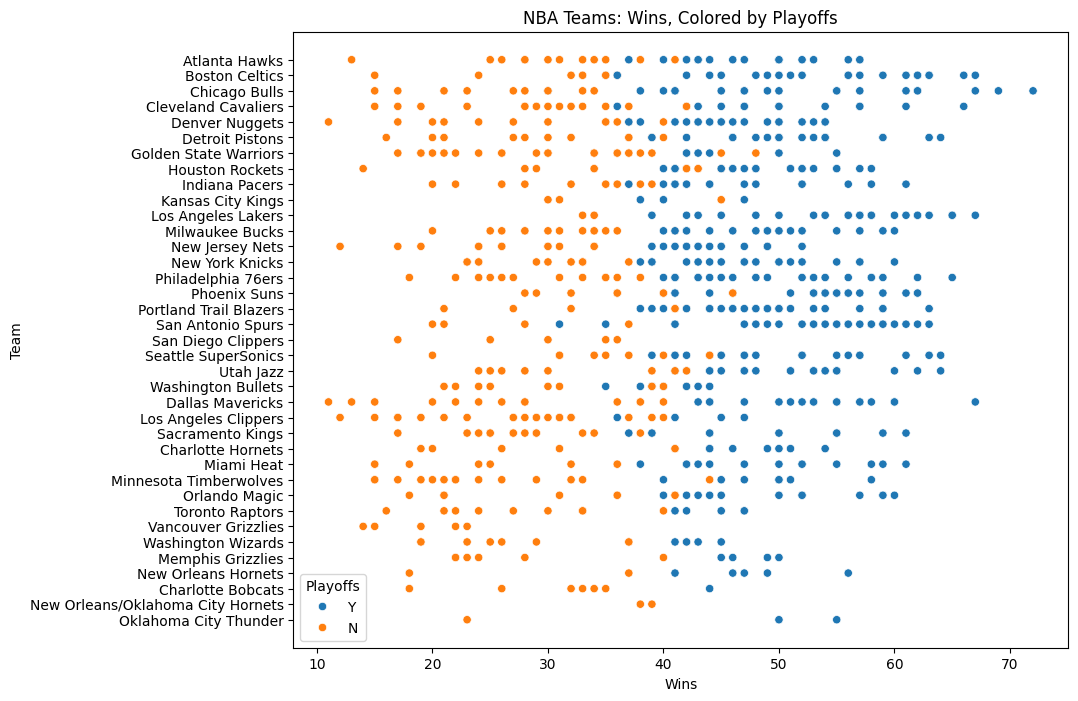

In [255]:
# scatter plot
df['Playoffs'] = df['Playoffs'].map({0: 'N', 1: 'Y'})

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='W', y='Team', hue='Playoffs')

plt.title('NBA Teams: Wins, Colored by Playoffs')
plt.xlabel('Wins')
plt.ylabel('Team')
plt.legend(title='Playoffs')
plt.show()

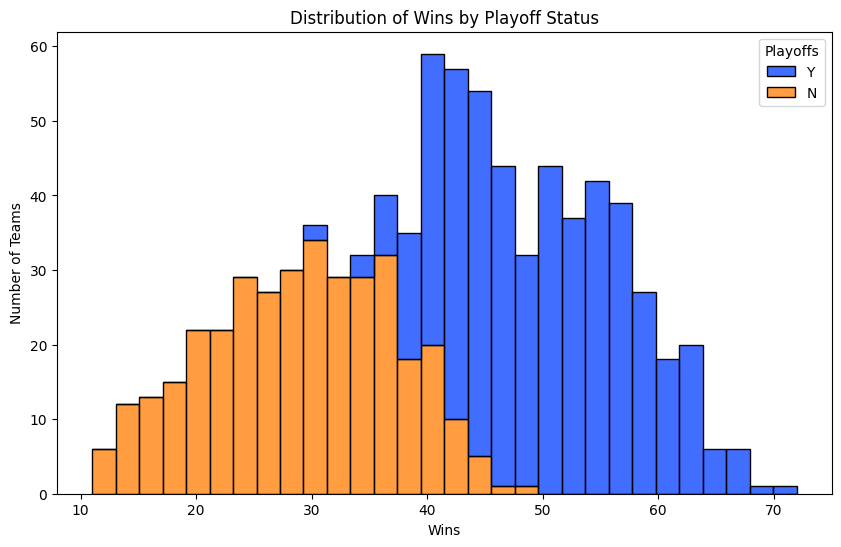

In [256]:
# histogram -- helps est. wins count for playoffs
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='W', hue='Playoffs', bins=30, multiple='stack', palette='bright', kde=False)
plt.title('Distribution of Wins by Playoff Status')
plt.xlabel('Wins')
plt.ylabel('Number of Teams')
plt.show()

#### Take a rough estimate, and now use that moving forward.  



In [257]:
WINS_NEED_TO_MAKE_PLAYOFFS = 42

---

# Now do moneyball but for the NBA. 

#### I would like you to do try and do this on your own first.  

It's not easy, but its fun af.  

There is a guided lecture on how to do this that I can send you, but I'd like for you to try and figure it out on your own first.  

If you are fully stuck, ask in slack how other people did it if that doesn't work (I highly encourage collorbration and learning from eachother.  I still consider that doing it on your own.)  

If that doesn't work, DM me and I will send you the lectures explaining how to do the whole thing.

# Rough Guide a v1 model.
0. Make a model to predict PTS 
0. For v1, dont use `2P, 3P, FG, or FT`.  Instead use `2PA, 3PA, FTA`.  
0. Include any other cols use see fit.  


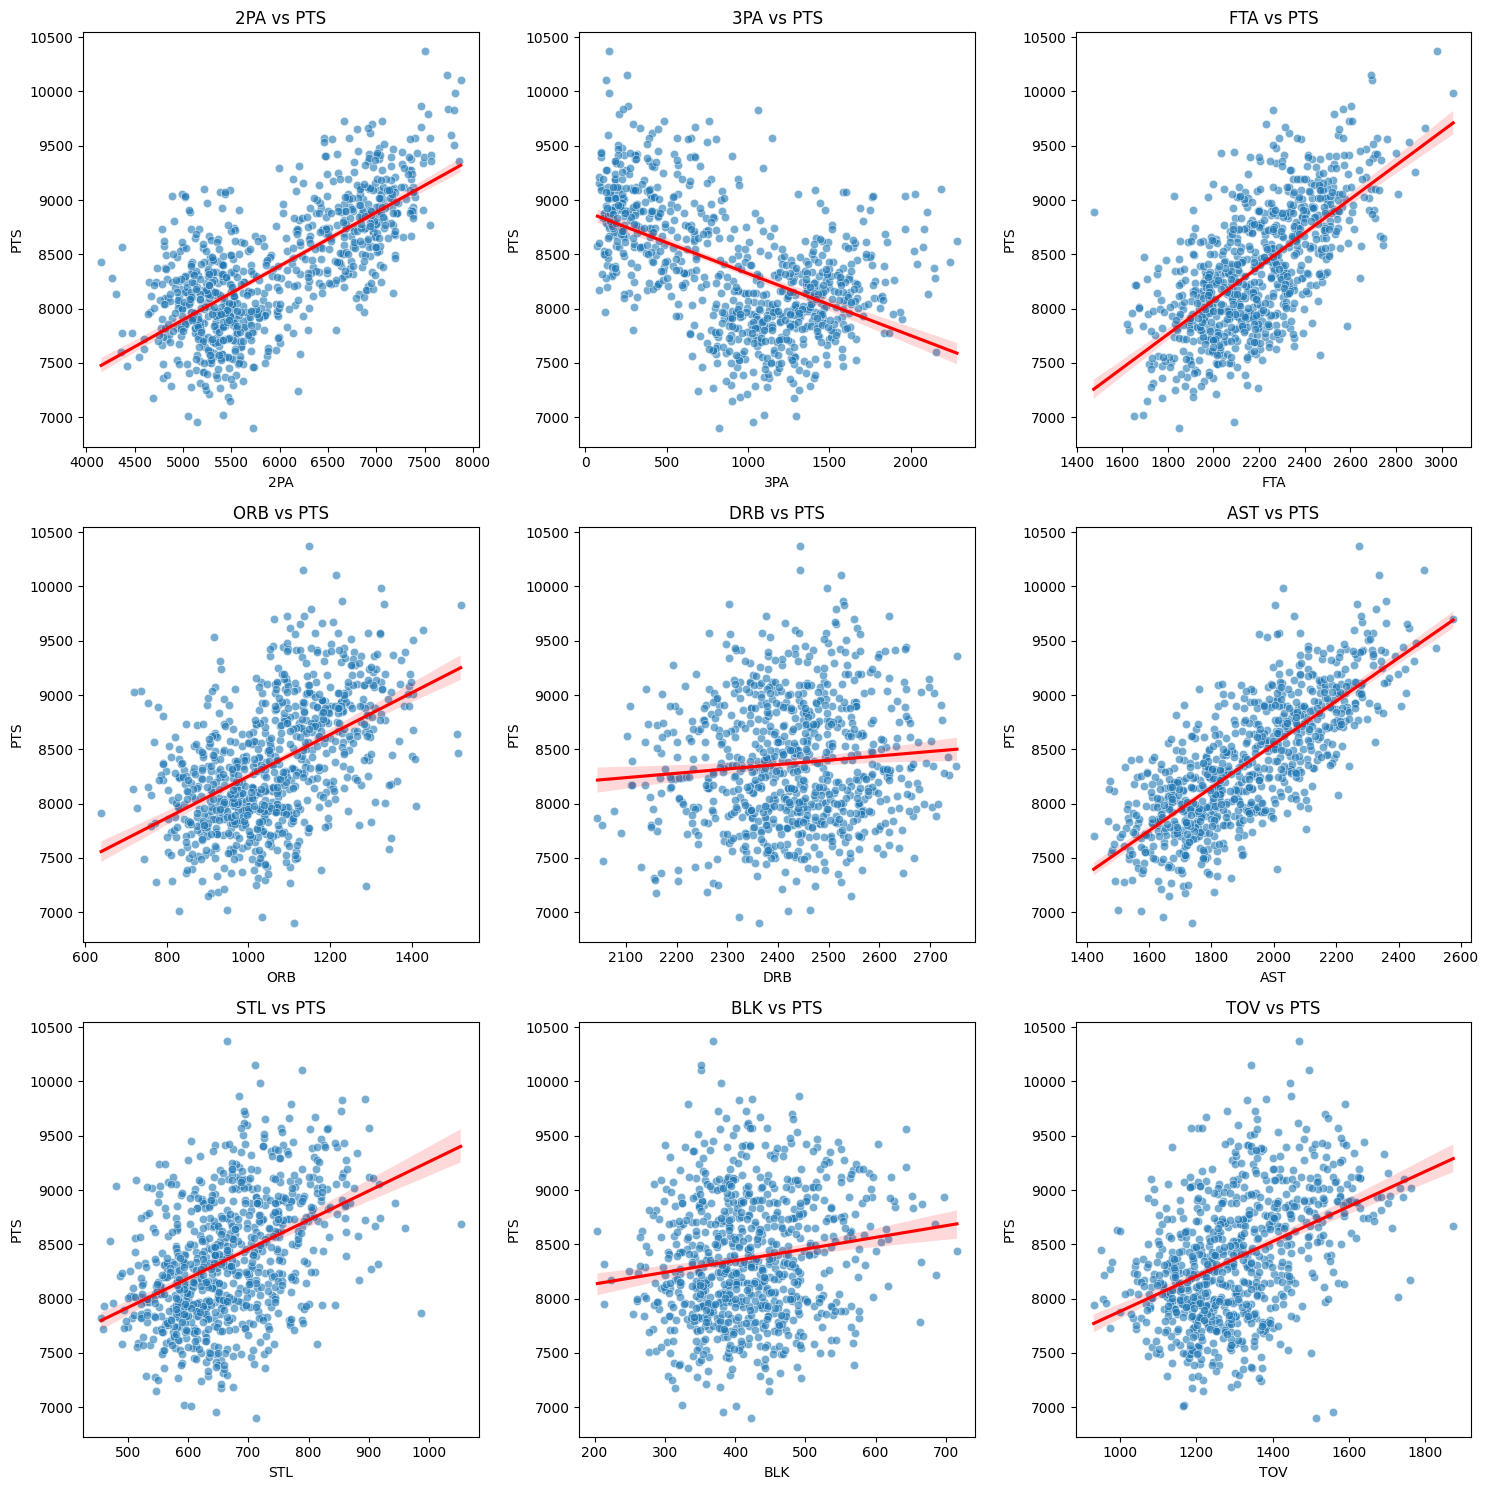

Variance Inflation Factors:
  feature          VIF
0   const  1004.571127
1     2PA    14.612764
2     3PA     9.827771
3     FTA     1.648202
4     ORB     3.320314
5     DRB     1.568583
6     AST     2.299700
7     STL     1.781731
8     BLK     1.264983
9     TOV     2.150146

Interpretation: VIF > 5 is moderate multicollinearity; VIF > 10 is severe.

R2 Score: 0.902
RMSE: 187.63

                            OLS Regression Results                            
Dep. Variable:                    PTS   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     643.8
Date:                Tue, 28 Oct 2025   Prob (F-statistic):          2.48e-319
Time:                        22:41:14   Log-Likelihood:                -4431.1
No. Observations:                 668   AIC:                             8882.
Df Residuals:                     658   BIC:               

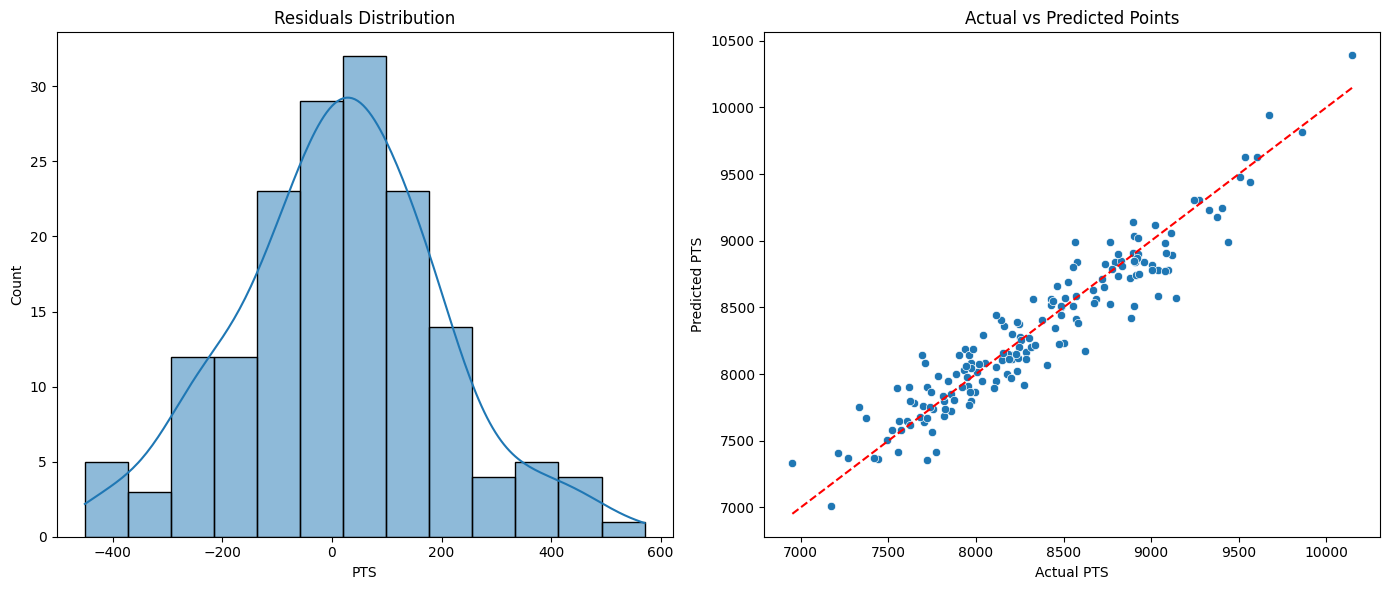

In [258]:
# isbe = inspect, select, build, evaluate

# select: features and target
features = ['2PA', '3PA', 'FTA', 'ORB', 'DRB', 'AST', 'STL', 'BLK', 'TOV']
X = df[features]
y = df['PTS']

# plot: PTS vs. all features
dependent_variable = 'PTS'
independent_variables = features

n = len(features)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()
for i, var in enumerate(features):
    sns.scatterplot(x=df[var], y=df[dependent_variable], ax=axes[i], alpha=0.6)
    sns.regplot(x=df[var], y=df[dependent_variable], ax=axes[i], scatter=False, color='red')
    axes[i].set_title(f'{var} vs {dependent_variable}')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# check multicollinearity
X_const = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data['feature'] = ['const'] + features
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print("Variance Inflation Factors:")
print(vif_data)
print("\nInterpretation: VIF > 5 is moderate multicollinearity; VIF > 10 is severe.\n")

# build model
model = LinearRegression()
model.fit(X_train, y_train)

# evaluate model
y_pred = model.predict(X_test)
print(f'R2 Score: {metrics.r2_score(y_test, y_pred):.3f}')
print(f'RMSE: {rmse(y_test, y_pred):.2f}')
print()

# summarize, regression based off slope-intercept
X_sm = sm.add_constant(X_train)
stats_model = sm.OLS(y_train, X_sm).fit()
print(stats_model.summary())

# plot
residuals = y_test - y_pred
plt.figure(figsize=(14, 6))

# residuals: ideally normally distributed (bell-shape) centered around zero.
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')

# scatterplot: clusters show how distant model predictions are to actual values
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual PTS')
plt.ylabel('Predicted PTS')
plt.title('Actual vs Predicted Points')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

# show residuals & scatterplot
plt.tight_layout()
plt.show()

### Interpretation

- **R2 Score: 0.902**: 90.2% of variance comes from predicted points scored (PTS) with the model; very strong fit

- **Adjusted R-squared: 0.897**: 89.7% of variance comes from predicted points scored (PTS) with the model; very close to **R2**

- **RMSE: 187.63**: average margin of error for predictions is ~188 points from actual; sufficient since PTS ranges between est. 7000-10,000 (see right chart)

- **Coefficients**
  - **2PA** (coef=1.05), **3PA** (coef=1.27), **FTA** (coef=1.14), **AST** (coef=0.91) -- more attempts and assists correlate with higher points
  - **ORB** (coef=-1.01), **STL** (coef=-0.27) -- defensive stats are negative predictors of points (decrease points)
  - **DRB**, **BLK**, **TOV** -- less significant or limited impact
    - **P-values** for these coefficients, **DRB** (p=0.749), **BLK** (p=0.917) & **TOV** (p=0.629), suggest insignificant impact on PTS in this model

- **Multicollinearity**: **2PA** (VIF=14.6) and **3PA** (VIF=9.8) have serious multicollinearity, meaning the variable is strongly linearly dependent on other features (shares redundant information with other predictors)

### How to address multicollinearity?

Ridge Regression (v2)?

In [259]:
from sklearn.linear_model import Ridge

In [260]:
# select
features = ['2PA', '3PA', 'FTA', 'ORB', 'DRB', 'AST', 'STL', 'BLK', 'TOV']
X = df[features]
y = df['PTS']

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# build model: Ridgw Regression -- increasing alpha can reduce/constrain coefficients (and multicollinearity)
ridge_model = Ridge(alpha=1000.0)
ridge_model.fit(X_train, y_train)

# evaluate model
y_pred = ridge_model.predict(X_test)
print(f'R2 Score (Ridge): {metrics.r2_score(y_test, y_pred):.3f}')
print(f'RMSE (Ridge): {rmse(y_test, y_pred):.2f}\n')

# summarize
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': ridge_model.coef_})
print(coef_df)

R2 Score (Ridge): 0.902
RMSE (Ridge): 187.63

  Feature  Coefficient
0     2PA     1.049978
1     3PA     1.267769
2     FTA     1.138524
3     ORB    -1.004930
4     DRB    -0.021759
5     AST     0.911575
6     STL    -0.266197
7     BLK     0.010137
8     TOV    -0.033184
